In [1]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib

In [3]:
df = pd.read_csv("/content/tourism_data.csv")
print(df.head())

   id          state              district       region  \
0   1            Goa  North Goa, South Goa   West India   
1   2         Ladakh           Leh, Kargil  North India   
2   3      Rajasthan                Jaipur  North India   
3   4  Uttar Pradesh              Varanasi  North India   
4   5  Uttar Pradesh                  Agra  North India   

                                   coordinates  altitude_m  popularity_score  \
0        {'latitude': 15.3, 'longitude': 73.8}          50                 9   
1      {'latitude': 34.16, 'longitude': 77.58}        3505                 9   
2  {'latitude': 26.9124, 'longitude': 75.7873}         431                 9   
3  {'latitude': 25.3176, 'longitude': 82.9739}          81                 9   
4  {'latitude': 27.1767, 'longitude': 78.0081}         171                10   

  accessibility                                    nearest_airport  \
0          Easy     {'name': 'Dabolim Airport', 'distance_km': 22}   
1      Moderate  {'name'

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df['coordinates'] = df['coordinates'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df['latitude'] = df['coordinates'].apply(lambda x: x.get('latitude', None))
df['longitude'] = df['coordinates'].apply(lambda x: x.get('longitude', None))

df.fillna({
    'popularity_score': df['popularity_score'].mean(),
    'safety_rating': df['safety_rating'].mean()
}, inplace=True)

In [6]:
df['target_score'] = (
    df['popularity_score'] * 0.6 +
    df['safety_rating'] * 0.4
)

features = ['latitude', 'longitude', 'ideal_days', 'popularity_score', 'safety_rating']
X = df[features]
y = df['target_score']

In [7]:
print(df.describe())


print(df[['popularity_score', 'safety_rating', 'ideal_days']].corr())

               id   altitude_m  popularity_score  minimum_days  ideal_days  \
count  100.000000   100.000000        100.000000    100.000000  100.000000   
mean    50.500000   963.110000          7.380000      1.950000    2.840000   
std     29.011492  1135.590052          1.440959      0.965307    1.275012   
min      1.000000     0.000000          4.000000      0.500000    0.500000   
25%     25.750000    60.000000          6.000000      1.000000    2.000000   
50%     50.500000   401.500000          7.000000      2.000000    3.000000   
75%     75.250000  1600.000000          9.000000      2.000000    3.000000   
max    100.000000  4350.000000         10.000000      6.000000    7.000000   

       maximum_days  safety_rating    latitude   longitude  target_score  
count    100.000000     100.000000  100.000000  100.000000    100.000000  
mean       4.650000       8.060000   22.081668   80.063252      7.652000  
std        2.244522       0.693695    7.956874    6.713631      0.981699

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [10]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [16]:
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
print("CV Score:", np.mean(scores))

CV Score: -0.03090360000000004


In [12]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.06633159999999937


In [13]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.9969457964267361
Test Score: 0.9479507219083495


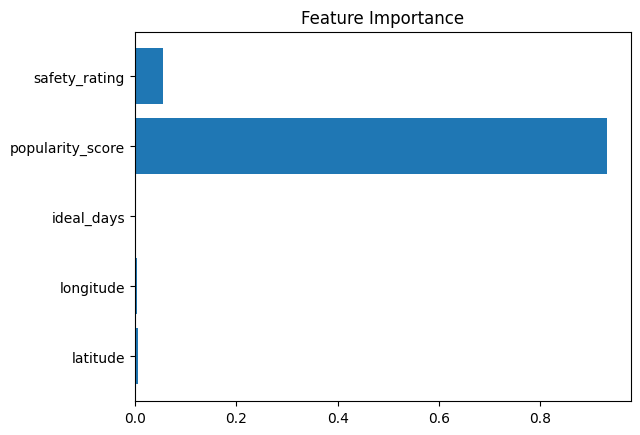

In [14]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.show()

In [40]:
joblib.dump(model, "tourism_recommendation_model.pkl")
print("Model Saved")

Model Saved


In [22]:
import pandas as pd
import numpy as np
import ast
import joblib
import requests

In [23]:
df = pd.read_csv("tourism_data.csv")

In [24]:
df['coordinates'] = df['coordinates'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Extract latitude & longitude
df['latitude'] = df['coordinates'].apply(lambda x: x['latitude'])
df['longitude'] = df['coordinates'].apply(lambda x: x['longitude'])

In [25]:
model = joblib.load("tourism_recommendation_model.pkl")

In [26]:
API_KEY = "e1bb66a75f94f3937490f5f3fda20486"

def get_weather(lat, lon):
    try:
        url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
        data = requests.get(url).json()

        return {
            "weather": data["weather"][0]["main"],
            "temperature": data["main"]["temp"]
        }
    except:
        return {"weather": "Unknown", "temperature": None}

In [35]:
df.head()

,id,state,district,region,coordinates,altitude_m,popularity_score,accessibility,nearest_airport,nearest_railway_station,...,user_reviews_summary,recent_developments,sustainability_notes,destination_name,permits_details,latitude,longitude,distance,ml_score,final_score
0,1,Goa,"North Goa, South Goa",West India,"{'latitude': 15.3, 'longitude': 73.8}",50,9,Easy,"{'name': 'Dabolim Airport', 'distance_km': 22}","{'name': 'Margao Railway Station', 'distance_k...",...,"Great mix of beaches, nightlife, and heritage;...",Improved coastal safety measures and upgraded ...,Plastic restrictions on several beaches; suppo...,Goa,Not required,15.3000,73.8000,12.995176,8.408,-4.587176
1,2,Ladakh,"Leh, Kargil",North India,"{'latitude': 34.16, 'longitude': 77.58}",3505,9,Moderate,{'name': 'Kushok Bakula Rimpochee Airport (Leh...,"{'name': 'Jammu Tawi', 'distance_km': 420}",...,Spectacular but demanding destination; prepara...,Road and airport upgrades and new homestays ha...,"Water is scarce; avoid plastic, use refillable...",Ladakh (Leh),Inner Line Permits required for areas like Nub...,34.1600,77.5800,16.171125,8.584,-7.587125
2,3,Rajasthan,Jaipur,North India,"{'latitude': 26.9124, 'longitude': 75.7873}",431,9,Easy,"{'name': 'Jaipur International Airport', 'dist...","{'name': 'Jaipur Junction', 'distance_km': 3}",...,Highly recommended for first-time visitors to ...,Tourism infrastructure and palace restoration ...,Support heritage conservation by using authori...,Jaipur,Not required,26.9124,75.7873,12.044632,8.616,-3.428632
3,4,Uttar Pradesh,Varanasi,North India,"{'latitude': 25.3176, 'longitude': 82.9739}",81,9,Easy,"{'name': 'Lal Bahadur Shastri Airport', 'dista...","{'name': 'Varanasi Junction / Kashi', 'distanc...",...,Intense but unforgettable experience; spiritua...,Major riverfront and infrastructure upgrades a...,River-cleaning and ghat conservation underway;...,Varanasi (Kashi),Not required,25.3176,82.9739,5.815937,8.384,2.568063
4,5,Uttar Pradesh,Agra,North India,"{'latitude': 27.1767, 'longitude': 78.0081}",171,10,Easy,{'name': 'Agra Airport (Pandit Deen Dayal Upad...,"{'name': 'Agra Cantt', 'distance_km': 3}",...,Must-see for Taj Mahal; most visitors stay 1–2...,Improved visitor facilities and e-ticketing sy...,Air-quality measures and traffic restrictions ...,Agra,Not required,27.1767,78.0081,10.442614,9.014,-1.428614


In [33]:
def recommend(user_lat, user_lon, df, model):

    df['distance'] = df.apply(
        lambda row: ((row['latitude'] - user_lat)**2 + (row['longitude'] - user_lon)**2)**0.5,
        axis=1
    )

    X = df[['latitude', 'longitude', 'ideal_days', 'popularity_score', 'safety_rating']]
    df['ml_score'] = model.predict(X)

    df['final_score'] = df['ml_score'] - df['distance']


    top = df.sort_values(by='final_score', ascending=False).head(5)


    weather_list = []
    temp_list = []

    for _, row in top.iterrows():
        weather = get_weather(row['latitude'], row['longitude'])
        weather_list.append(weather['weather'])
        temp_list.append(weather['temperature'])

    top['weather'] = weather_list
    top['temperature'] = temp_list

    return top[['destination_name', 'distance', 'weather', 'temperature']]

In [36]:
user_lat = 56.6754
user_lon = 85.8178

result = recommend(user_lat, user_lon, df, model)

print("\n Recommended Places:\n")
print(result)


 Recommended Places:

                            destination_name   distance weather  temperature
1                               Ladakh (Leh)  23.975083  Clouds        -2.42
17                Pangong Lake (Pangong Tso)  23.999638   Clear        -6.78
16                              Nubra Valley  23.496787  Clouds        -1.93
95  Gulmarg (Kashmir Ski & Snow Destination)  25.352160  Clouds         6.64
12                                    Manali  25.911101  Clouds         6.56


In [37]:
import joblib
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

joblib.dump(model, "tourism_recommendation_model.pkl")

print("✅ Model saved successfully")

✅ Model saved successfully


In [41]:
import joblib

model = joblib.load("tourism_recommendation_model.pkl")

print(" Model loaded successfully")

 Model loaded successfully
